In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_telecom_churn.csv to cleaned_telecom_churn.csv


In [13]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4960 entries, 0 to 4959
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        4960 non-null   object 
 1   Tenure            4960 non-null   int64  
 2   InternetService   4960 non-null   object 
 3   Contract          4960 non-null   object 
 4   MonthlyCharges    4960 non-null   float64
 5   TotalCharges      4960 non-null   float64
 6   PaymentMethod     4960 non-null   object 
 7   Churn             4960 non-null   object 
 8   TenureBucket      4960 non-null   object 
 9   HighRiskCustomer  4960 non-null   object 
 10  RevenueSegment    4960 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 426.4+ KB


In [25]:
#Created Analysis Dataset (Exclude Unknowns)
eda_df = df[
    (df['InternetService'] != 'unknown') &
    (df['PaymentMethod'] != 'unknown')
].copy()

In [26]:
print("Dataset Shape:", df.shape)
display(df.head())
display(df.describe())

Dataset Shape: (4960, 11)


,CustomerID,Tenure,InternetService,Contract,MonthlyCharges,TotalCharges,PaymentMethod,Churn,TenureBucket,HighRiskCustomer,RevenueSegment
0,C00001,66,fiber optic,month-to-month,140.00,9859.85,electronic check,yes,49-72 Months,No,High Value
1,C00002,17,fiber optic,one year,92.01,1576.77,electronic check,yes,13-24 Months,No,High Value
2,C00003,57,fiber optic,month-to-month,105.94,5161.17,bank transfer,no,49-72 Months,No,High Value
3,C00004,47,fiber optic,one year,41.25,2183.39,mailed check,no,25-48 Months,No,Medium Value
4,C00005,32,dsl,one year,123.04,4145.68,credit card,no,25-48 Months,No,High Value


,Tenure,MonthlyCharges,TotalCharges
count,4960.000000,4960.000000,4960.000000
mean,35.979637,70.110282,2525.599194
std,21.054290,24.406571,1830.614410
min,0.000000,15.000000,0.000000
25%,18.000000,52.965000,1045.352500
50%,36.000000,70.210000,2187.575000
75%,54.000000,86.520000,3681.057500
max,72.000000,140.000000,10341.060000


Dataset contains cleaned telecom customer records with engineered churn-related features for downstream analysis.

Churn
no     69.48
yes    30.52
Name: proportion, dtype: float64


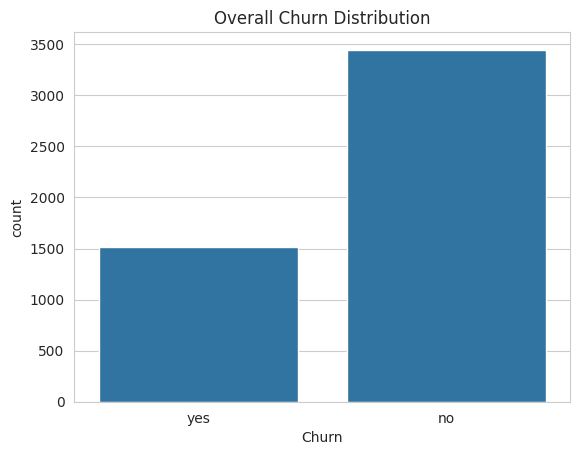

In [27]:
churn_rate = (df['Churn'].value_counts(normalize=True) * 100).round(2)
print(churn_rate)

sns.countplot(data=df, x='Churn')
plt.title("Overall Churn Distribution")
plt.show()

Overall churn rate is 30%, establishing baseline customer attrition.

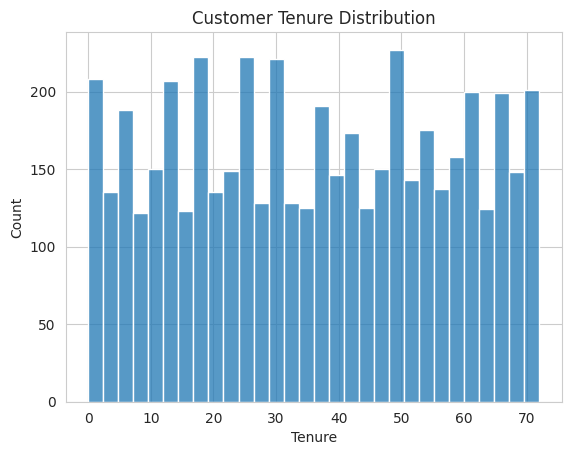

In [28]:
sns.histplot(df['Tenure'], bins=30)
plt.title("Customer Tenure Distribution")
plt.show()

Customer tenure distribution shows concentration in early/mid lifecycle stages.

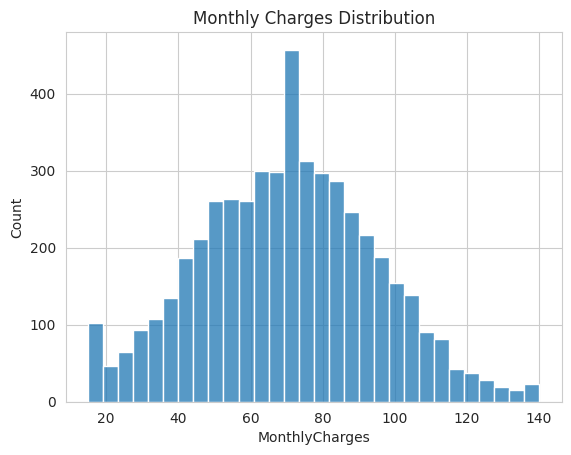

In [29]:
sns.histplot(df['MonthlyCharges'], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

Monthly charges are distributed across low to premium pricing tiers.

Churn,no,yes
TenureBucket,,
0-12 Months,50.12,49.88
13-24 Months,73.87,26.13
25-48 Months,71.22,28.78
49-72 Months,74.55,25.45


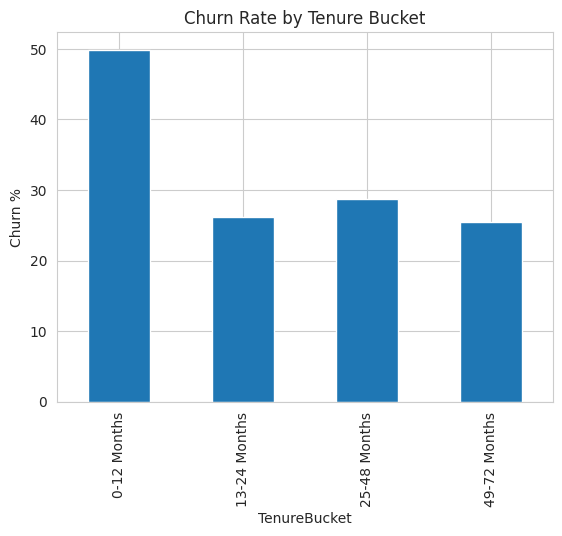

In [30]:
tenure_churn = pd.crosstab(
    eda_df['TenureBucket'],
    eda_df['Churn'],
    normalize='index'
) * 100

display(tenure_churn.round(2))

tenure_churn['yes'].plot(kind='bar')
plt.title("Churn Rate by Tenure Bucket")
plt.ylabel("Churn %")
plt.show()

Early-tenure customers exhibit the highest churn.

Churn,no,yes
InternetService,,
dsl,77.89,22.11
fiber optic,58.92,41.08
no internet,75.73,24.27


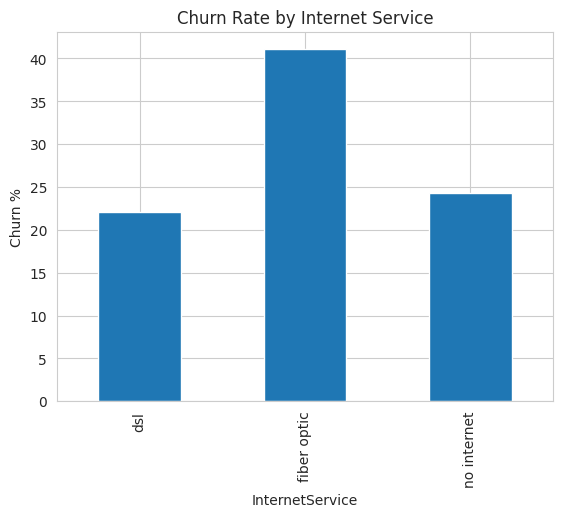

In [31]:
internet_churn = pd.crosstab(
    eda_df['InternetService'],
    eda_df['Churn'],
    normalize='index'
) * 100

display(internet_churn.round(2))

internet_churn['yes'].plot(kind='bar')
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn %")
plt.show()

Fiber optic customers churn more than other service segments.

Churn,no,yes
Contract,,
month-to-month,58.18,41.82
one year,83.85,16.15
two year,80.41,19.59


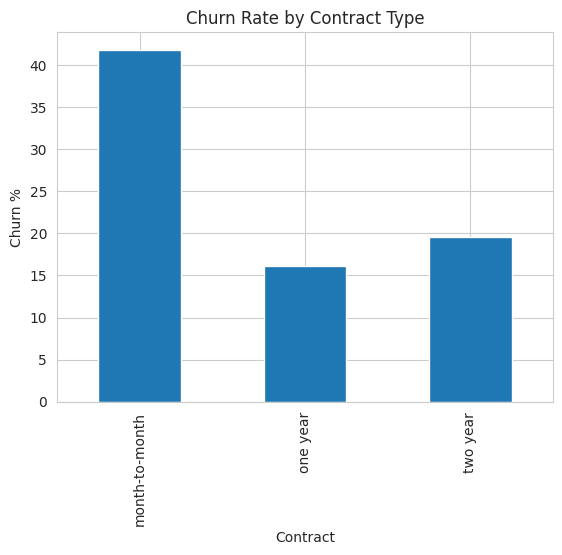

In [32]:
contract_churn = pd.crosstab(
    eda_df['Contract'],
    eda_df['Churn'],
    normalize='index'
) * 100

display(contract_churn.round(2))

contract_churn['yes'].plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn %")
plt.show()

Month-to-month contracts have significantly higher churn.

Churn,no,yes
PaymentMethod,,
bank transfer,70.80,29.20
credit card,69.66,30.34
electronic check,67.37,32.63
mailed check,70.35,29.65


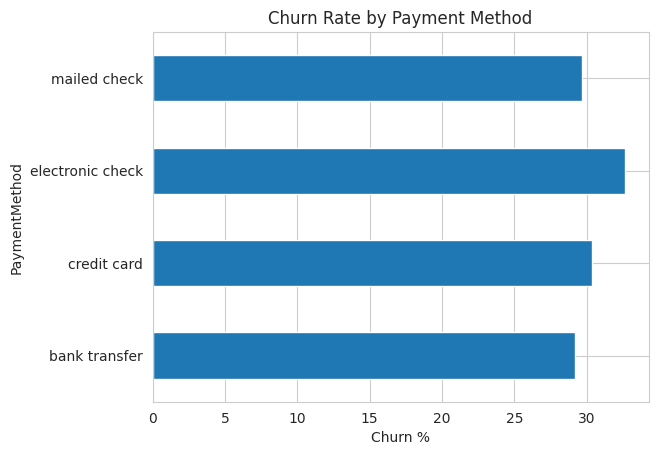

In [33]:
payment_churn = pd.crosstab(
    eda_df['PaymentMethod'],
    eda_df['Churn'],
    normalize='index'
) * 100

display(payment_churn.round(2))

payment_churn['yes'].plot(kind='barh')
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn %")
plt.show()

Electronic check users exhibit elevated churn.

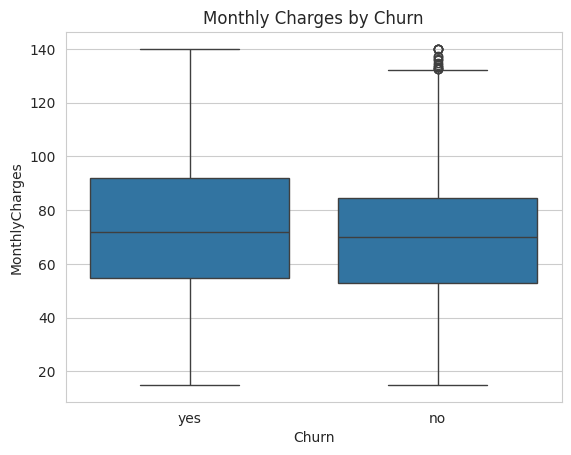

In [34]:
sns.boxplot(data=eda_df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges by Churn")
plt.show()

Churned customers generally have higher monthly charges.

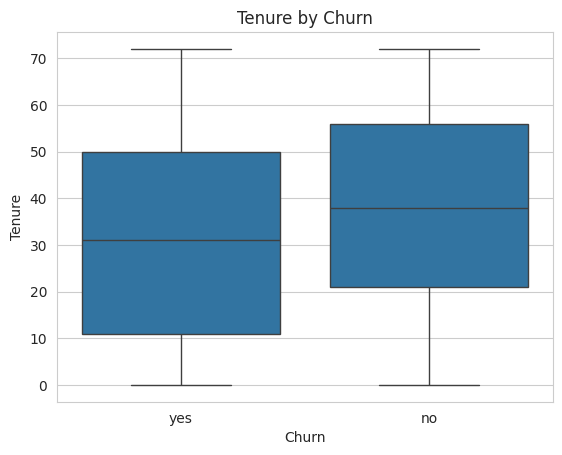

In [35]:
sns.boxplot(data=eda_df, x='Churn', y='Tenure')
plt.title("Tenure by Churn")
plt.show()

Churned customers have lower average tenure.

In [36]:
monthly_loss = eda_df[
    eda_df['Churn'] == 'yes'
]['MonthlyCharges'].sum()

annual_loss = monthly_loss * 12

print("Monthly Revenue at Risk:", round(monthly_loss,2))
print("Annual Revenue at Risk:", round(annual_loss,2))

Monthly Revenue at Risk: 105158.59
Annual Revenue at Risk: 1261903.08


Churn contributes significant annualized revenue risk.

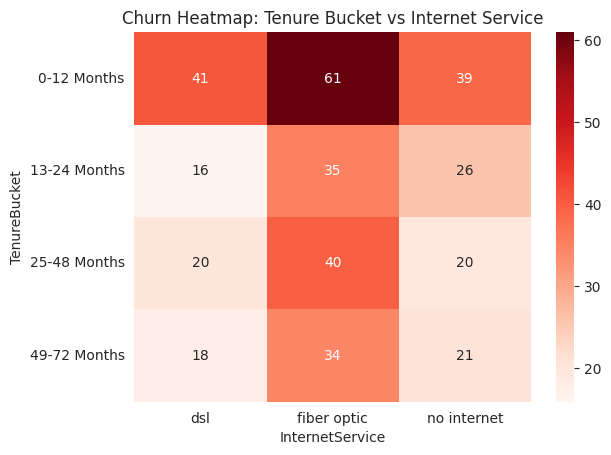

In [37]:
segment_heatmap = pd.crosstab(
    [eda_df['TenureBucket'], eda_df['InternetService']],
    eda_df['Churn'],
    normalize='index'
) * 100

heatmap_data = segment_heatmap['yes'].unstack()

sns.heatmap(heatmap_data, annot=True, cmap='Reds')
plt.title("Churn Heatmap: Tenure Bucket vs Internet Service")
plt.show()

Highest churn occurs among early-tenure fiber optic customers.

In [ ]:
## Key Findings
#Early-tenure customers are the most churn-prone
#Fiber optic users churn disproportionately
#Month-to-month contracts strongly drive churn
#Higher monthly charges correlate with churn
#Revenue-at-risk is concentrated in specific high-risk segments